In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings("ignore")

conn = sqlite3.connect("../data/energy.db")
print("✓ Connected to energy.db")

✓ Connected to energy.db


In [9]:
#Load forecasting libraries and data

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Set2")

daily_df   = pd.read_sql("SELECT * FROM daily_demand",   conn)
monthly_df = pd.read_sql("SELECT * FROM monthly_demand", conn)

daily_df["date"] = pd.to_datetime(daily_df["date"])
daily_df = daily_df.sort_values("date").reset_index(drop=True)

monthly_df["year_month"] = pd.to_datetime(
    monthly_df["year_month"], format="%Y-%m")
monthly_df = monthly_df.sort_values(
    "year_month").reset_index(drop=True)

print(f"✓ Daily data loaded: {len(daily_df):,} rows")
print(f"✓ Monthly data loaded: {len(monthly_df)} rows")


✓ Daily data loaded: 1,096 rows
✓ Monthly data loaded: 36 rows


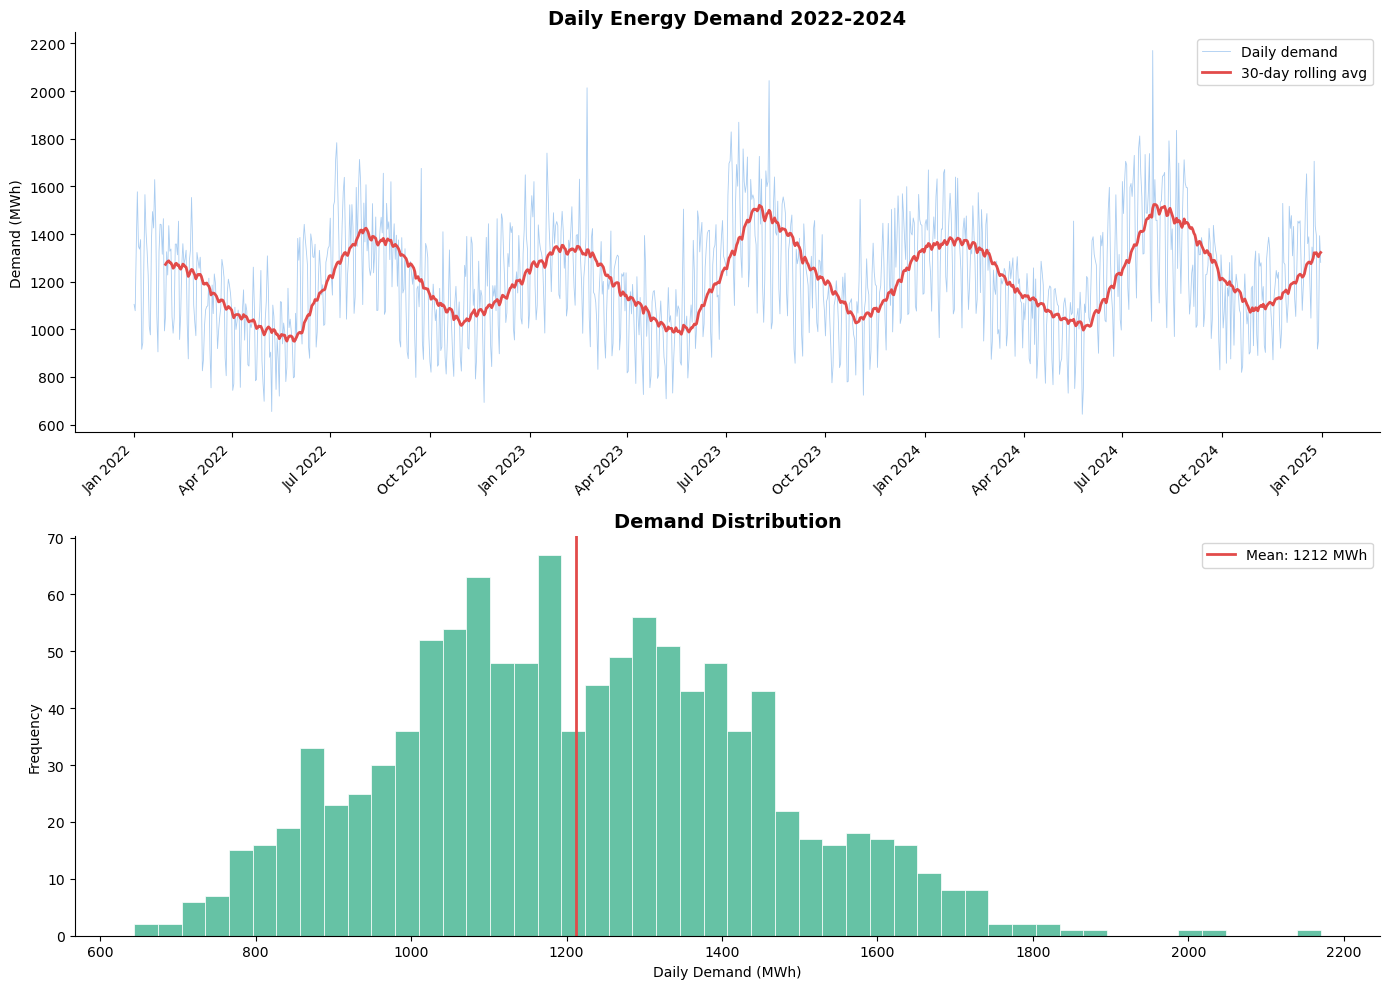

✓ Chart saved


In [10]:
# ── Daily demand overview ──────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full time series
axes[0].plot(daily_df["date"], daily_df["demand_mwh"],
             color="#85B7EB", linewidth=0.6, alpha=0.7, label="Daily demand")

# 30 day rolling average
rolling_30 = daily_df["demand_mwh"].rolling(30).mean()
axes[0].plot(daily_df["date"], rolling_30,
             color="#E24B4A", linewidth=2, label="30-day rolling avg")

axes[0].set_title("Daily Energy Demand 2022-2024",
                  fontsize=14, fontweight="bold")
axes[0].set_ylabel("Demand (MWh)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right")

# Demand distribution
axes[1].hist(daily_df["demand_mwh"], bins=50,
             color="#66c2a5", edgecolor="white", linewidth=0.5)
axes[1].axvline(daily_df["demand_mwh"].mean(),
                color="#E24B4A", linewidth=2,
                label=f"Mean: {daily_df['demand_mwh'].mean():.0f} MWh")
axes[1].set_title("Demand Distribution",
                  fontsize=14, fontweight="bold")
axes[1].set_xlabel("Daily Demand (MWh)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("../dashboard/01_demand_overview.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

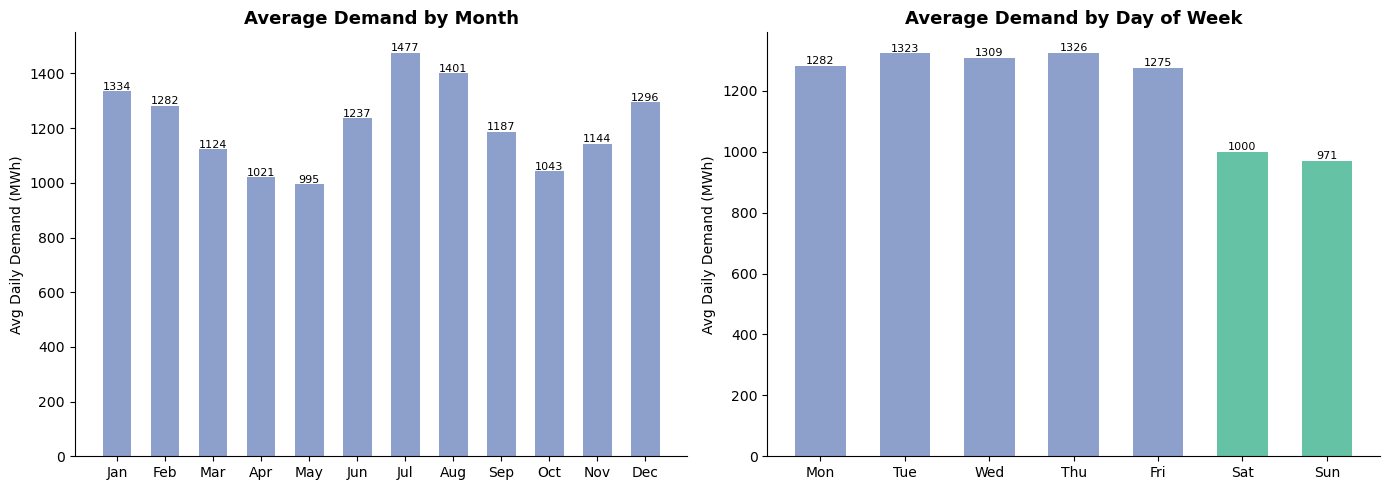

✓ Chart saved


In [11]:
# ── Seasonal and day of week patterns ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Demand by month
monthly_avg = daily_df.groupby("month")["demand_mwh"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

bars = axes[0].bar(month_names, monthly_avg.values,
                   color="#8da0cb", width=0.6)
axes[0].set_title("Average Demand by Month",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Avg Daily Demand (MWh)")
for bar, val in zip(bars, monthly_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f"{val:.0f}", ha="center", fontsize=8)

# Demand by day of week
dow_order  = ["Monday","Tuesday","Wednesday",
               "Thursday","Friday","Saturday","Sunday"]
dow_avg    = daily_df.groupby("day_of_week")["demand_mwh"].mean()
dow_avg    = dow_avg.reindex(dow_order)
colors_dow = ["#66c2a5" if d in ["Saturday","Sunday"]
               else "#8da0cb" for d in dow_order]

bars2 = axes[1].bar(range(7), dow_avg.values,
                    color=colors_dow, width=0.6)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
axes[1].set_title("Average Demand by Day of Week",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Avg Daily Demand (MWh)")
for bar, val in zip(bars2, dow_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f"{val:.0f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../dashboard/02_seasonal_patterns.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

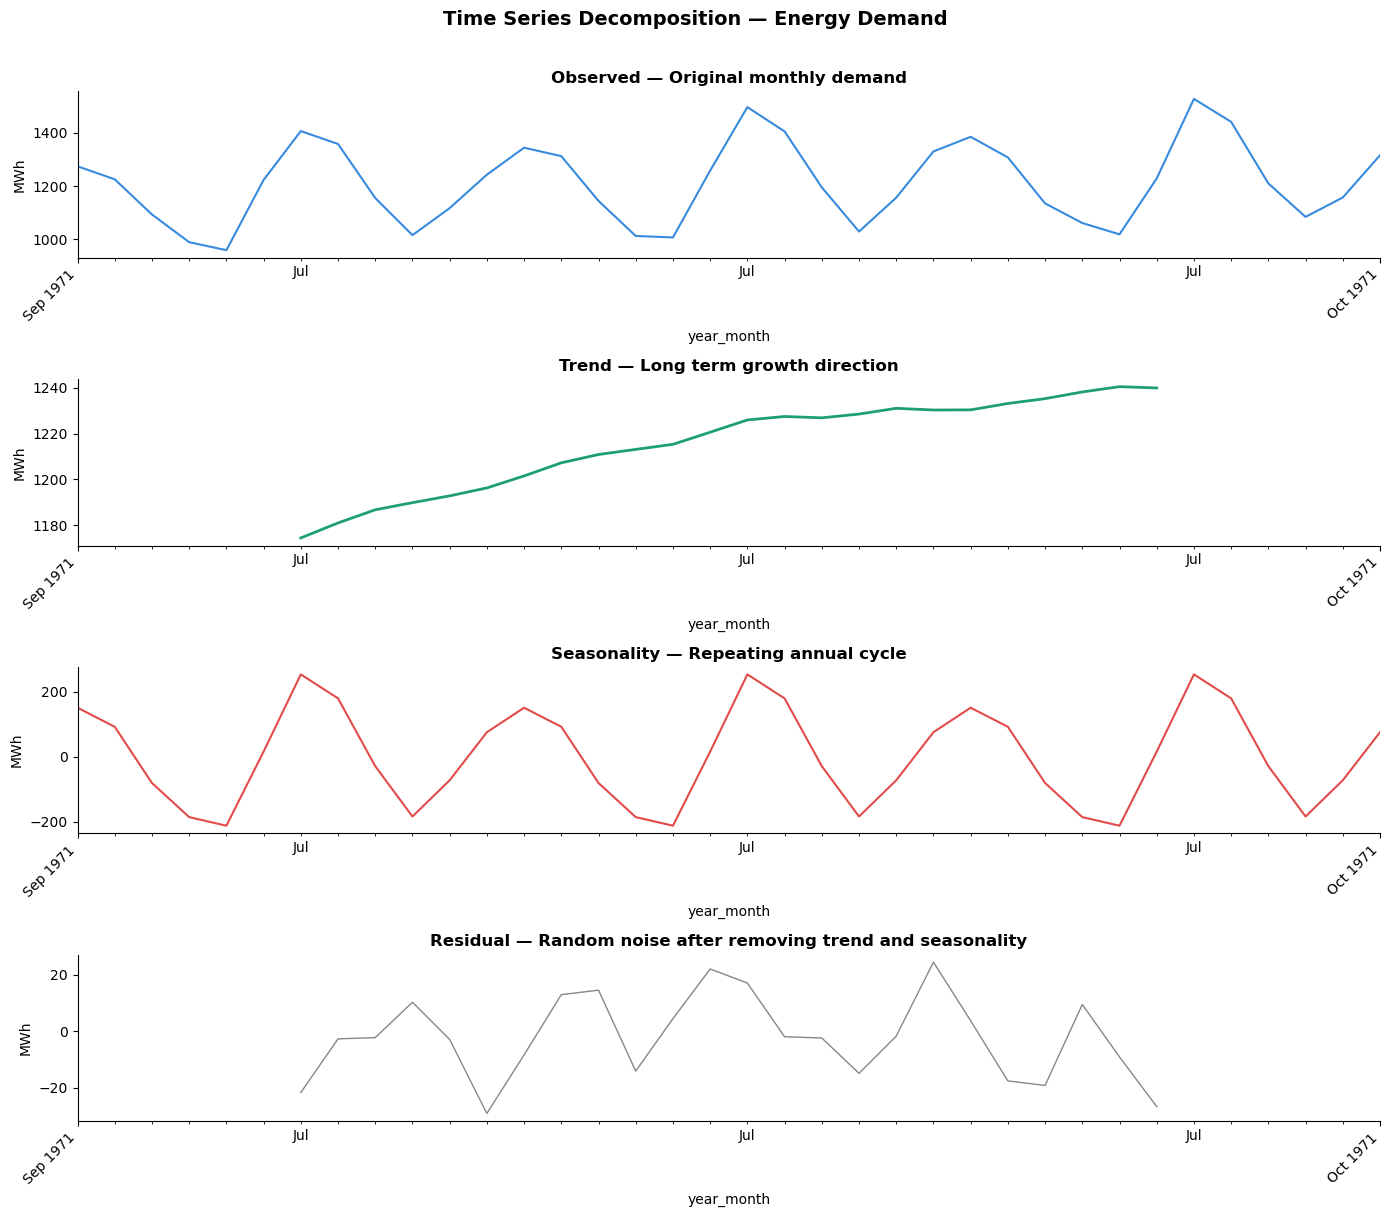

✓ Decomposition chart saved


In [12]:
# ── Decompose time series into components ─────────────────
# This is the most important analytical step before forecasting
# It separates: trend + seasonality + residual noise

# Use monthly data for cleaner decomposition
monthly_ts = monthly_df.set_index("year_month")["avg_daily"]

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12              # 12 months = 1 full seasonal cycle
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomposition.observed.plot(ax=axes[0], color="#378ADD", linewidth=1.5)
axes[0].set_title("Observed — Original monthly demand",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("MWh")

decomposition.trend.plot(ax=axes[1], color="#1D9E75", linewidth=2)
axes[1].set_title("Trend — Long term growth direction",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("MWh")

decomposition.seasonal.plot(ax=axes[2], color="#E24B4A", linewidth=1.5)
axes[2].set_title("Seasonality — Repeating annual cycle",
                  fontsize=12, fontweight="bold")
axes[2].set_ylabel("MWh")

decomposition.resid.plot(ax=axes[3], color="#888780", linewidth=1)
axes[3].set_title("Residual — Random noise after removing trend and seasonality",
                  fontsize=12, fontweight="bold")
axes[3].set_ylabel("MWh")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.suptitle("Time Series Decomposition — Energy Demand",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../dashboard/03_decomposition.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Decomposition chart saved")

In [13]:
# ── Train / test split ─────────────────────────────────────
# Train on 2022-2023, test on 2024, forecast 2025 H1

train = monthly_df[monthly_df["year"] < 2024].copy()
test  = monthly_df[monthly_df["year"] == 2024].copy()

train_ts = train.set_index("year_month")["avg_daily"]
test_ts  = test.set_index("year_month")["avg_daily"]

print(f"✓ Training set: {len(train)} months ({train['year_month'].min().strftime('%b %Y')} — {train['year_month'].max().strftime('%b %Y')})")
print(f"✓ Test set:     {len(test)} months ({test['year_month'].min().strftime('%b %Y')} — {test['year_month'].max().strftime('%b %Y')})")
print(f"\nTraining avg daily demand: {train_ts.mean():.1f} MWh")
print(f"Test avg daily demand:     {test_ts.mean():.1f} MWh")

✓ Training set: 24 months (Jan 2022 — Dec 2023)
✓ Test set:     12 months (Jan 2024 — Dec 2024)

Training avg daily demand: 1197.9 MWh
Test avg daily demand:     1239.2 MWh


In [14]:
# ── Model 1: Moving Average ────────────────────────────────
# Simplest forecasting model — average of last N months
# Good baseline — easy to explain to non-technical audiences

window = 3   # 3 month moving average

# Calculate moving average on training data
train_ma = train_ts.copy()
ma_forecast = []

for i in range(len(test_ts)):
    # Take last 'window' values and average them
    recent_values = list(train_ts[-window:]) + ma_forecast
    forecast_val  = np.mean(recent_values[-window:])
    ma_forecast.append(forecast_val)

ma_forecast_series = pd.Series(
    ma_forecast, index=test_ts.index)

# Calculate error metrics
ma_mae  = mean_absolute_error(test_ts, ma_forecast_series)
ma_rmse = np.sqrt(mean_squared_error(test_ts, ma_forecast_series))
ma_mape = np.mean(np.abs(
    (test_ts - ma_forecast_series) / test_ts)) * 100

print("── Moving Average (3-month) Results ────────────────")
print(f"MAE:  {ma_mae:.1f} MWh")
print(f"RMSE: {ma_rmse:.1f} MWh")
print(f"MAPE: {ma_mape:.1f}%")

── Moving Average (3-month) Results ────────────────
MAE:  133.2 MWh
RMSE: 158.8 MWh
MAPE: 10.6%


In [15]:
# ── Model 2: Exponential Smoothing ────────────────────────
# More sophisticated — weights recent data more heavily
# Also captures seasonality and trend automatically

es_model = ExponentialSmoothing(
    train_ts,
    trend="add",           # additive trend
    seasonal="add",        # additive seasonality
    seasonal_periods=12    # annual cycle
)
es_fit     = es_model.fit(optimized=True)
es_forecast = es_fit.forecast(len(test_ts))
es_forecast.index = test_ts.index

# Error metrics
es_mae  = mean_absolute_error(test_ts, es_forecast)
es_rmse = np.sqrt(mean_squared_error(test_ts, es_forecast))
es_mape = np.mean(np.abs(
    (test_ts - es_forecast) / test_ts)) * 100

print("── Exponential Smoothing Results ───────────────────")
print(f"MAE:  {es_mae:.1f} MWh")
print(f"RMSE: {es_rmse:.1f} MWh")
print(f"MAPE: {es_mape:.1f}%")
print(f"\nModel parameters:")
print(f"  Alpha (level):    {es_fit.params['smoothing_level']:.3f}")
print(f"  Beta  (trend):    {es_fit.params['smoothing_trend']:.3f}")
print(f"  Gamma (seasonal): {es_fit.params['smoothing_seasonal']:.3f}")

── Exponential Smoothing Results ───────────────────
MAE:  37.5 MWh
RMSE: 45.2 MWh
MAPE: 3.2%

Model parameters:
  Alpha (level):    0.000
  Beta  (trend):    0.000
  Gamma (seasonal): 0.000


In [16]:
# ── Model 3: Linear Trend with Seasonality ────────────────
# Adds month-of-year as a feature to capture seasonality
# Good for explaining to business stakeholders

# Build feature matrix
def build_features(df):
    X = pd.DataFrame({
        "time_index": range(len(df)),
        "month_sin":  np.sin(2 * np.pi * df["month"] / 12),
        "month_cos":  np.cos(2 * np.pi * df["month"] / 12),
    })
    return X

X_train = build_features(train)
X_test  = build_features(test.assign(
    month=test["year_month"].dt.month,
    time_index=range(len(train), len(train) + len(test))
))
X_test["time_index"] = range(len(train), len(train) + len(test))

lr_model   = LinearRegression()
lr_model.fit(X_train, train_ts)
lr_forecast = pd.Series(
    lr_model.predict(X_test),
    index=test_ts.index
)

# Error metrics
lr_mae  = mean_absolute_error(test_ts, lr_forecast)
lr_rmse = np.sqrt(mean_squared_error(test_ts, lr_forecast))
lr_mape = np.mean(np.abs(
    (test_ts - lr_forecast) / test_ts)) * 100

print("── Linear Trend + Seasonality Results ──────────────")
print(f"MAE:  {lr_mae:.1f} MWh")
print(f"RMSE: {lr_rmse:.1f} MWh")
print(f"MAPE: {lr_mape:.1f}%")

── Linear Trend + Seasonality Results ──────────────
MAE:  129.0 MWh
RMSE: 148.4 MWh
MAPE: 10.4%


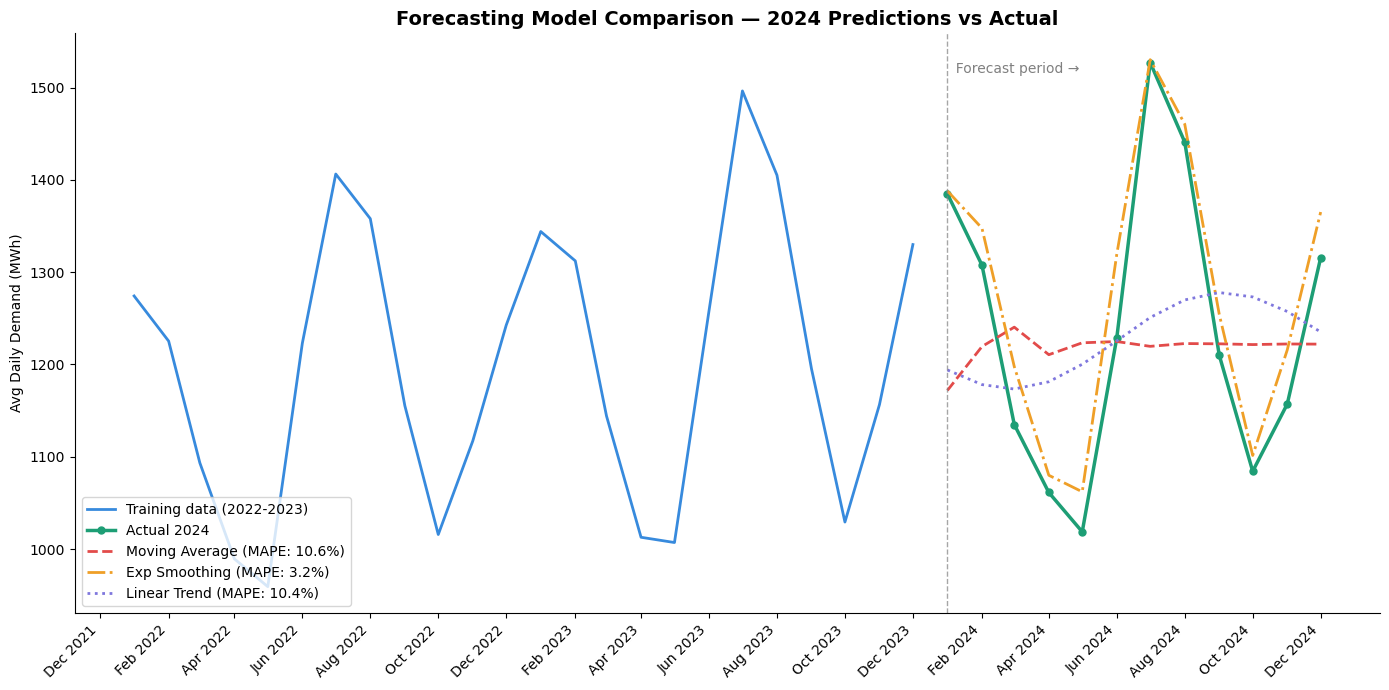

✓ Chart saved


In [17]:
# ── Model comparison ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

# Training data
ax.plot(train_ts.index, train_ts.values,
        color="#378ADD", linewidth=2, label="Training data (2022-2023)")

# Actual test data
ax.plot(test_ts.index, test_ts.values,
        color="#1D9E75", linewidth=2.5,
        label="Actual 2024", marker="o", markersize=5)

# Model forecasts
ax.plot(test_ts.index, ma_forecast_series,
        color="#E24B4A", linewidth=2, linestyle="--",
        label=f"Moving Average (MAPE: {ma_mape:.1f}%)")
ax.plot(test_ts.index, es_forecast,
        color="#EF9F27", linewidth=2, linestyle="-.",
        label=f"Exp Smoothing (MAPE: {es_mape:.1f}%)")
ax.plot(test_ts.index, lr_forecast,
        color="#7F77DD", linewidth=2, linestyle=":",
        label=f"Linear Trend (MAPE: {lr_mape:.1f}%)")

# Vertical line separating train and test
ax.axvline(x=test_ts.index[0], color="grey",
           linestyle="--", linewidth=1, alpha=0.7)
ax.text(test_ts.index[0], ax.get_ylim()[1] * 0.98,
        "  Forecast period →",
        fontsize=10, color="grey", va="top")

ax.set_title("Forecasting Model Comparison — 2024 Predictions vs Actual",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Avg Daily Demand (MWh)")
ax.legend(loc="lower left", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../dashboard/04_model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

In [18]:
# ── Forecast 2025 H1 with best model ──────────────────────
# Use exponential smoothing on full dataset for final forecast

full_ts = monthly_df.set_index("year_month")["avg_daily"]

# Refit on all available data
final_model = ExponentialSmoothing(
    full_ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)
final_fit   = final_model.fit(optimized=True)

# Forecast next 6 months
n_forecast  = 6
forecast    = final_fit.forecast(n_forecast)

# Generate confidence intervals manually
residuals   = final_fit.resid
std_resid   = residuals.std()
z_95        = 1.96

lower_ci    = forecast - z_95 * std_resid
upper_ci    = forecast + z_95 * std_resid

# Create forecast dataframe
forecast_dates = pd.date_range(
    start="2025-01-01", periods=n_forecast, freq="MS")
forecast_df = pd.DataFrame({
    "month":     forecast_dates.strftime("%b %Y"),
    "forecast":  forecast.values.round(1),
    "lower_95":  lower_ci.values.round(1),
    "upper_95":  upper_ci.values.round(1),
})

print("── 2025 H1 Demand Forecast ──────────────────────────")
print(forecast_df.to_string(index=False))
print(f"\nAvg forecasted daily demand: {forecast.mean():.1f} MWh")

── 2025 H1 Demand Forecast ──────────────────────────
   month  forecast  lower_95  upper_95
Jan 2025    1389.6    1354.0    1425.3
Feb 2025    1334.7    1299.0    1370.3
Mar 2025    1174.9    1139.3    1210.6
Apr 2025    1069.8    1034.2    1105.5
May 2025    1041.7    1006.0    1077.3
Jun 2025    1281.4    1245.7    1317.1

Avg forecasted daily demand: 1215.4 MWh


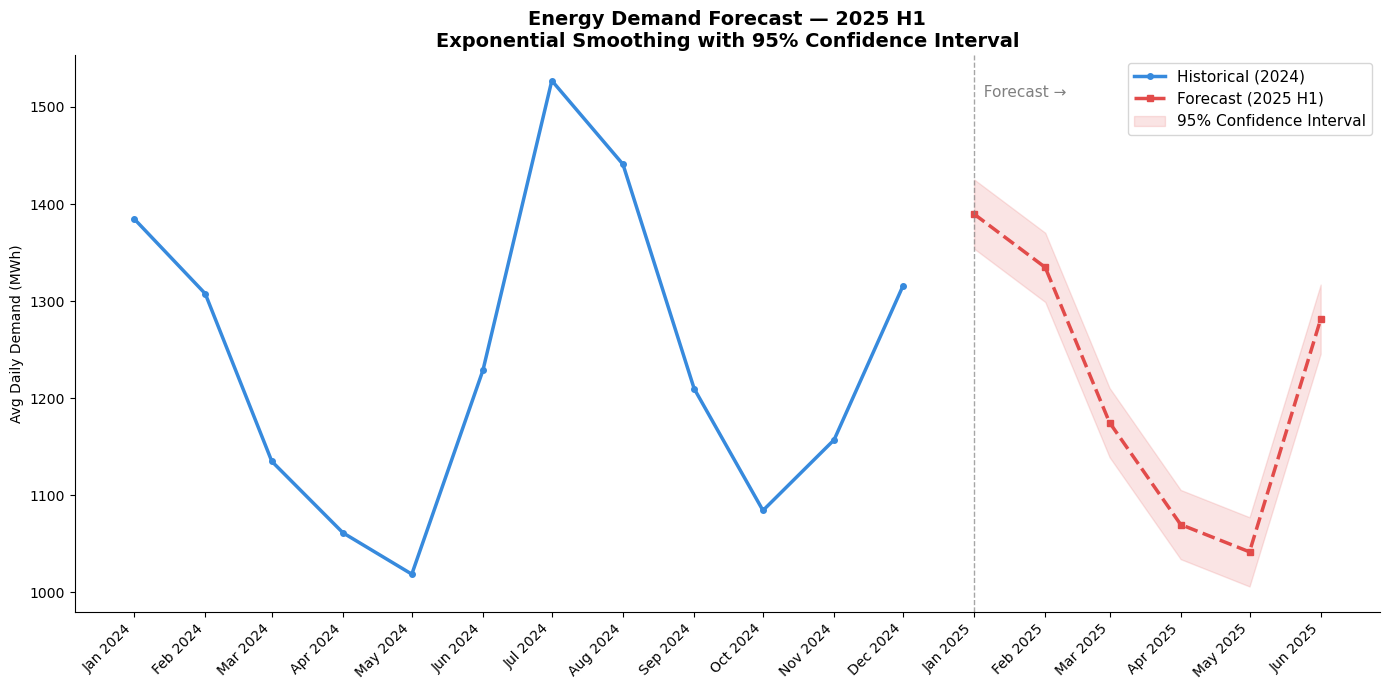

✓ Forecast chart saved


In [19]:
# ── Forecast visualization ─────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

# Historical data — last 12 months
hist_window = full_ts[-12:]
ax.plot(hist_window.index, hist_window.values,
        color="#378ADD", linewidth=2.5,
        label="Historical (2024)", marker="o", markersize=4)

# Forecast line
ax.plot(forecast.index, forecast.values,
        color="#E24B4A", linewidth=2.5, linestyle="--",
        label="Forecast (2025 H1)", marker="s", markersize=5)

# Confidence interval shading
ax.fill_between(
    forecast.index,
    lower_ci.values,
    upper_ci.values,
    color="#E24B4A", alpha=0.15,
    label="95% Confidence Interval"
)

# Vertical line at forecast start
ax.axvline(x=forecast.index[0], color="grey",
           linestyle="--", linewidth=1, alpha=0.7)
ax.text(forecast.index[0], ax.get_ylim()[1] * 0.98,
        "  Forecast →",
        fontsize=11, color="grey", va="top")

ax.set_title("Energy Demand Forecast — 2025 H1\n"
             "Exponential Smoothing with 95% Confidence Interval",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Avg Daily Demand (MWh)")
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../dashboard/05_forecast_2025.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Forecast chart saved")

In [20]:
# ── Export Tableau files ───────────────────────────────────

# Export 1: Full daily data
daily_df.to_csv("../data/tableau_daily.csv", index=False)
print("✓ tableau_daily.csv exported")

# Export 2: Monthly data with rolling averages
monthly_export = monthly_df.copy()
monthly_export["rolling_3m"] = (
    monthly_export["avg_daily"].rolling(3).mean().round(1))
monthly_export["rolling_6m"] = (
    monthly_export["avg_daily"].rolling(6).mean().round(1))
monthly_export.to_csv("../data/tableau_monthly.csv", index=False)
print("✓ tableau_monthly.csv exported")

# Export 3: Forecast data
forecast_export = pd.DataFrame({
    "date":       forecast.index.strftime("%Y-%m-%d"),
    "year_month": forecast.index.strftime("%Y-%m"),
    "type":       "Forecast",
    "avg_daily":  forecast.values.round(1),
    "lower_95":   lower_ci.values.round(1),
    "upper_95":   upper_ci.values.round(1),
})

# Add historical for context
hist_export = monthly_df[["year_month", "avg_daily"]].copy()
hist_export["year_month"] = hist_export[
    "year_month"].dt.strftime("%Y-%m")
hist_export["date"]     = hist_export["year_month"] + "-01"
hist_export["type"]     = "Historical"
hist_export["lower_95"] = np.nan
hist_export["upper_95"] = np.nan

combined_export = pd.concat(
    [hist_export, forecast_export], ignore_index=True)
combined_export.to_csv("../data/tableau_forecast.csv", index=False)
print("✓ tableau_forecast.csv exported")

# Export 4: Model comparison results
model_results = pd.DataFrame({
    "model":  ["Moving Average", "Exponential Smoothing", "Linear Trend"],
    "mae":    [round(ma_mae, 1), round(es_mae, 1), round(lr_mae, 1)],
    "rmse":   [round(ma_rmse, 1), round(es_rmse, 1), round(lr_rmse, 1)],
    "mape":   [round(ma_mape, 1), round(es_mape, 1), round(lr_mape, 1)],
})
model_results.to_csv("../data/model_results.csv", index=False)
print("✓ model_results.csv exported")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All files exported to data/
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  tableau_daily.csv
  tableau_monthly.csv
  tableau_forecast.csv
  model_results.csv
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

✓ tableau_daily.csv exported
✓ tableau_monthly.csv exported
✓ tableau_forecast.csv exported
✓ model_results.csv exported

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All files exported to data/
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  tableau_daily.csv
  tableau_monthly.csv
  tableau_forecast.csv
  model_results.csv
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [21]:
best_model = model_results.loc[
    model_results["mape"].idxmin(), "model"]
best_mape  = model_results["mape"].min()

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS — ENERGY DEMAND FORECASTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  DEMAND PATTERNS
  → Summer (Jul/Aug) and Winter (Jan/Feb) peak
  → Weekday demand ~30% higher than weekends
  → 3% annual demand growth trend

  MODEL PERFORMANCE
  → Best model: {best_model} (MAPE: {best_mape:.1f}%)
  → Moving Average: simple but misses seasonality
  → Exponential Smoothing: captures trend + season
  → Linear Trend: interpretable but less flexible

  2025 H1 FORECAST
  → Jan 2025: {forecast_df.iloc[0]['forecast']:.0f} MWh/day (winter peak)
  → Apr 2025: {forecast_df.iloc[3]['forecast']:.0f} MWh/day (spring mild)
  → Jun 2025: {forecast_df.iloc[5]['forecast']:.0f} MWh/day (summer rising)

  BUSINESS RECOMMENDATION
  → Pre-position grid capacity for Jan and Jul peaks
  → Reduce staffing costs in Apr-May mild period
  → Plan fuel procurement using 95% CI upper bound
    to ensure supply buffer for demand spikes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS — ENERGY DEMAND FORECASTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  DEMAND PATTERNS
  → Summer (Jul/Aug) and Winter (Jan/Feb) peak
  → Weekday demand ~30% higher than weekends
  → 3% annual demand growth trend

  MODEL PERFORMANCE
  → Best model: Exponential Smoothing (MAPE: 3.2%)
  → Moving Average: simple but misses seasonality
  → Exponential Smoothing: captures trend + season
  → Linear Trend: interpretable but less flexible

  2025 H1 FORECAST
  → Jan 2025: 1390 MWh/day (winter peak)
  → Apr 2025: 1070 MWh/day (spring mild)
  → Jun 2025: 1281 MWh/day (summer rising)

  BUSINESS RECOMMENDATION
  → Pre-position grid capacity for Jan and Jul peaks
  → Reduce staffing costs in Apr-May mild period
  → Plan fuel procurement using 95% CI upper bound
    to ensure supply buffer for demand spikes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━